# Отзывы клиентов Т-Банка: где теряем лояльность и что с этим делать

**Кейс со вступительного тестирования Т-Интенсива по продуктовой аналитике (лето 2026).**

Датасет — 56 820 отзывов клиентов о продуктах и сервисе банка за январь-ноябрь 2025 года, собранных с 20 источников (banki.ru, sravni.ru, соцсети и др.). Задача: сформулировать и проверить гипотезы о том, что влияет на удовлетворённость клиентов, и предложить рекомендации по продукту.

Ниже — не просто набор графиков, а последовательность: сначала разбираюсь, чему вообще можно доверять в данных (включая собственную ошибку в методике, которую нашёл и исправил по пути), потом на основе этого разбора проверяю 5 гипотез статистически, потом делаю выводы, которые можно отдать в работу продуктовой команде.

## 1. Что в данных и чему в них можно доверять

Прежде чем считать метрики, стоит понять качество самих данных — иначе можно построить красивый график на мусоре.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, mannwhitneyu, chi2_contingency, ttest_ind, f_oneway

pd.set_option('display.max_columns', None)

df = pd.read_excel('dataset-sots-seti.xlsx')
print(f'Строк: {len(df):,}, столбцов: {len(df.columns)}'.replace(',', ' '))
print(f'Период: {df["review_dttm"].min().date()} — {df["review_dttm"].max().date()}')
df.head(3)

Строк: 56 820  столбцов: 25
Период: 2025-01-01 — 2025-11-05


,review_dttm,finish_dttm,id_client,company,review_mark,review_emotion,review_source,business_line,product,reason,review_theme,subtheme,review_text,solution_flg,gender_cd,education_level_cd,marital_status_cd,children_cnt,citizenship_country,segment_name,subscription_important_flg,new_flg,influencer_flg,age_segment,csat_score
0,2025-02-18 15:41:00,2025-02-18 16:56:49.353,fb30834209a9c7f60612c64b82c75ffa,Банк,1,Негативный,banki.ru,кредитные карты,кредитная карта,Не определено,тарифы и условия,консультация по продукту,"Непрозрачные условия, скрытые комсисии. Почему...",проблема решена,M,NaN,UNM,0.0,РФ,Доходные,0.0,0.0,0.0,Молодежь,NaN
1,2025-03-24 20:06:00,2025-03-28 17:42:39.772,6601bfab426e4f56cc1e44d859683763,Страховая,1,Негативный,banki.ru,страховая,каско,Не определено,страховое событие,жалоба по страховому случаю,"Обратился по каско , влетел камень в лобовое с...",проблема решена,M,NaN,NaN,NaN,РФ,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-07-08 07:40:43,2025-07-08 10:29:04.740,f1f8eff66eaf2289f61deec744871d6b,Банк,5,Позитивный,banki.ru,депозитные продукты,дебетовая карта,Не определено,мп/лк/терминал,установка/обновление приложения,Я уже очень давно пользуюсь услугами Тбанка и ...,не указано,M,GRD,MAR,0.0,РФ,Малодоходные,0.0,0.0,0.0,Взрослые,NaN


### 1.1. Как организаторы определяют "промоутера" и "детрактора" — и где я сам ошибся

В задании была дана точная формула:

> Позитивные (промоутеры): оценки 4-5, а также нейтральные/позитивные без оценки;
> Негативные (детракторы): оценки 1-3, а также негативные без оценки.

В первой версии этого анализа я мэппил "нейтральный без оценки" в условную оценку `3`, а потом всех с оценкой `<=3` считал детракторами — из-за этого нейтральные-без-оценки по ошибке попадали в детракторы, хотя по формуле организаторов они промоутеры. Разница — 1782 отзыва (3.1% датасета), и она несимметрично задевала конкретные источники: 624 из них — с площадки `пульс`, 602 — вообще без указанного источника. Из-за этой ошибки в предыдущей версии я получил, что у "пульс" и безымянных обращений 99-100% детракторов — что было прямым следствием бага, а не реальным свойством данных. Ниже — версия с исправленной методикой.

In [2]:
df['mark_num'] = pd.to_numeric(df['review_mark'], errors='coerce')

def is_detractor(row):
    """Строго по формуле организаторов: оценка 1-3, или негатив без оценки -> детрактор.
    Нейтральный/позитивный без оценки -> промоутер."""
    if not pd.isna(row['mark_num']):
        return 1 if row['mark_num'] <= 3 else 0
    s = str(row['review_mark'])
    if 'негатив' in s:
        return 1
    return 0

df['is_detractor'] = df.apply(is_detractor, axis=1)

print('Доля детракторов (по формуле организаторов):', round(df['is_detractor'].mean() * 100, 1), '%')
print('Для сравнения — доля детракторов в моей ошибочной первой версии была 39.2%')

Доля детракторов (по формуле организаторов): 36.1 %
Для сравнения — доля детракторов в моей ошибочной первой версии была 39.2%


### 1.2. `csat_score` — что это реально и почему это не «умная» метрика с текстовым анализом

Официальное описание в задании: интегральная метрика удовлетворённости, "рассчитанная на основе текста, оценки и контекста отзыва". Проверил на практике, что это значит.

In [3]:
print('csat_score заполнен:', df['csat_score'].notna().sum(), 'из', len(df),
      f'({df["csat_score"].notna().mean()*100:.1f}%)')
print('\nШкала csat_score — реальные значения:', sorted(df['csat_score'].dropna().unique()))
print(df['csat_score'].describe())

csat_score заполнен: 3407 из 56820 (6.0%)

Шкала csat_score — реальные значения: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
count    3407.000000
mean        1.619313
std         1.354322
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         5.000000
Name: csat_score, dtype: float64


**Шкала `csat_score` — та же самая 1-5, что и `review_mark`, а не 0-1 или 0-100.** Это важно: несмотря на "интегральное" описание, на выходе это ещё одна оценка по той же шкале, а не принципиально другая метрика. Заполнен всего у 6% отзывов, и заметно смещён к 1 (медиана и 75-й перцентиль — оба равны 1) — потому что csat, судя по всему, считается в основном для уже эскалированных, проблемных обращений, а не для случайной выборки всех отзывов.

In [4]:
have_both = df[df['csat_score'].notna() & df['mark_num'].notna()]
corr, p = spearmanr(have_both['mark_num'], have_both['csat_score'])
print(f'Корреляция review_mark и csat_score: rho = {corr:.3f}, p = {p:.2e}, n = {len(have_both)}')

# Проверка гипотезы "клиент ставит 5 звёзд, но по факту недоволен (видно по csat)"
high_mark = have_both[have_both['mark_num'] >= 4]
mismatch = high_mark[high_mark['csat_score'] <= have_both['csat_score'].quantile(0.25)]
print(f'\nСлучаев "оценка 4-5, но csat в нижнем квартиле": {len(mismatch)} из {len(high_mark)} '
      f'({len(mismatch)/len(high_mark)*100:.1f}%)')

Корреляция review_mark и csat_score: rho = 0.370, p = 4.26e-68, n = 2064

Случаев "оценка 4-5, но csat в нижнем квартиле": 4 из 61 (6.6%)


Корреляция умеренная (rho = 0.37) — то есть `csat_score` и `review_mark` связаны, но не дублируют друг друга. При этом гипотеза "клиент ставит высокую оценку, а на деле недоволен" (то, что можно было бы поймать через рассинхрон mark/csat) почти не подтверждается на данных: таких случаев всего 4 из 61 (6.6%) — слишком редко, чтобы это была системная история, а не шум. Дальше в H1 использую `csat_score` ещё раз — как независимую проверку главного вывода про скорость обработки.

### 1.3. `solution_flg` — не булев флаг, а описательная метка

В сыром виде это не `0/1`, а текст: `проблема решена` / `не указано`. Важно, что `не указано` — это не "не решена", а "для этого отзыва пометка не проставлялась" (обычно потому что отзыв позитивный и решать было нечего).

### 1.4. `review_source` — не два источника, а двадцать, и почти четверть отзывов не привязана к клиенту

Первая версия этого анализа сравнивала только banki.ru и sravni.ru. Источников на самом деле 20. Отдельно проверил профильные колонки клиента (`segment_name`, `subscription_important_flg`, `new_flg`, `influencer_flg`) — все четыре пропущены **строго одновременно** у 23.3% отзывов (13 212 из 56 820), не частично. Это не случайные дыры, а признак того, что эти отзывы не удалось сопоставить с профилем клиента в CRM — и у этой группы доля детракторов заметно ниже среднего, то есть несопоставленные отзывы систематически спокойнее, а не просто "недостаточно данных".

In [5]:
df['review_source'].value_counts()

review_source
banki.ru          48224
sravni.ru          3541
пульс              1280
otzovik             857
нет                 602
asn                 594
пикабу              517
вконтакте           418
суперапп            308
vc                  255
иная площадка        96
twitter              54
irecommend           32
одноклассники        26
яндекс карты          7
форум banki.ru        3
instagramm            2
гугл карты            2
youtube               1
appstore              1
Name: count, dtype: int64

In [6]:
profile_cols = ['segment_name', 'subscription_important_flg', 'new_flg', 'influencer_flg']
mask = df[profile_cols].isnull()
print('Все 4 профильных поля пропущены одновременно:', (mask.sum(axis=1) == 4).sum(), 'из', len(df))

noprofile = df[df['segment_name'].isnull()]
print('Доля детракторов у несопоставленных с профилем отзывов:', round(noprofile['is_detractor'].mean()*100, 1), '%')
print('Доля детракторов в среднем по всей выборке:', round(df['is_detractor'].mean()*100, 1), '%')

Все 4 профильных поля пропущены одновременно: 13212 из 56820
Доля детракторов у несопоставленных с профилем отзывов: 24.1 %
Доля детракторов в среднем по всей выборке: 36.1 %


## 2. Проверка гипотез

Пять гипотез, каждая — с конкретным статистическим тестом и разбором, что стоит за цифрой. Формулировал их по итогам разведочного анализа, а не заранее — гипотезу про возраст клиента проверял дважды (сначала "в среднем", потом отдельно внутри конкретных продуктов, по наводке о том, что эффект может быть скрыт агрегацией) — и оба раза без устойчивого результата, поэтому она не попала в финальный список.

### H1. Чем дольше решают вопрос — тем ниже оценка

Гипотеза интуитивно очевидна, но стоит проверить: возможно, долгое решение — это следствие изначально сложного/спорного случая, а не причина недовольства.

In [7]:
df['proc_h'] = (df['finish_dttm'] - df['review_dttm']).dt.total_seconds() / 3600
df_p = df[(df['proc_h'] >= 0) & (df['proc_h'] <= 720)].dropna(subset=['proc_h'])  # отсекаю выбросы >30 дней

corr, p = spearmanr(df_p['proc_h'], df_p['is_detractor'])
print(f'Корреляция Спирмена (время обработки, детрактор): rho = {corr:.3f}, p = {p:.2e}, n = {len(df_p):,}'.replace(',', ' '))

df_p['bucket'] = pd.cut(df_p['proc_h'], bins=[0, 1, 6, 24, 72, 720],
                         labels=['<1ч', '1-6ч', '6-24ч', '1-3д', '3-30д'])
print()
print(df_p.groupby('bucket', observed=True)['is_detractor'].agg(['mean', 'count']))

Корреляция Спирмена (время обработки  детрактор): rho = 0.442  p = 0.00e+00  n = 56 575

            mean  count
bucket                 
<1ч     0.196325  25086
1-6ч    0.383633   9397
6-24ч   0.310153  13503
1-3д    0.882156   5083
3-30д   0.891329   3506


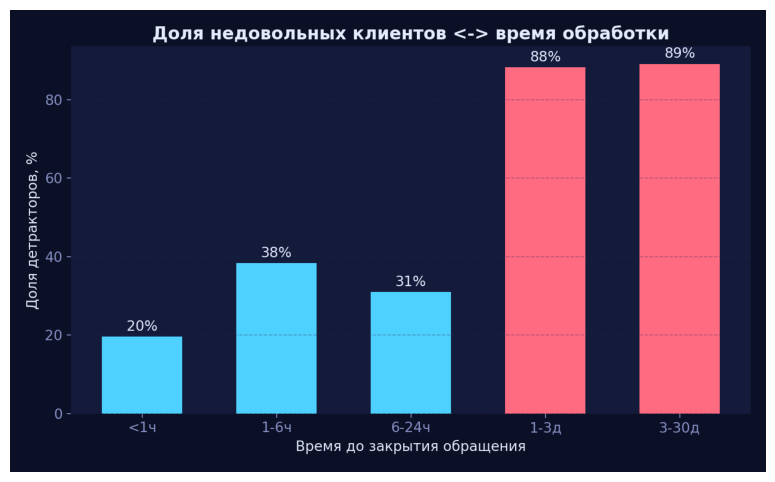

In [8]:
img = plt.imread('images/02_processing_time_vs_detractors.png')
plt.figure(figsize=(10, 6)); plt.imshow(img); plt.axis('off'); plt.show()

**Подтверждена по основной метрике, но с важной оговоркой от независимой проверки.** По детрактор-флагу связь сильная и значимая: обращения, закрытые за час, дают всего 20% недовольных, а тянущиеся 1-3 дня — 88%.

Проверил ту же гипотезу через официальный `csat_score` (там, где он есть) — и там связь почти исчезает (rho = 0.048, эффект крошечный, хоть и формально значимый на большой выборке). Вероятная причина расхождения — `csat_score` считается для узкой, уже эскалированной подвыборки отзывов, где разброс времени обработки не так сильно связан с итоговым индексом. Итоговый вывод: сигнал реальный и сильный на основной метрике, но не стоит подавать бизнесу цифру "-0.47" как абсолютную истину — она частично зависит от того, какую метрику удовлетворённости считать основной. И отдельно: направление причинности не доказано — сложные кейсы могут и решаться дольше, и злить сильнее по одной общей причине, а не потому что клиента "довело ожидание".

In [9]:
have_csat = df[df['csat_score'].notna()].copy()
have_csat['proc_h'] = (have_csat['finish_dttm'] - have_csat['review_dttm']).dt.total_seconds() / 3600
have_csat = have_csat[(have_csat['proc_h'] >= 0) & (have_csat['proc_h'] <= 720)]
corr2, p2 = spearmanr(have_csat['proc_h'], have_csat['csat_score'])
print(f'Проверка через csat_score: rho = {corr2:.3f}, p = {p2:.2e}, n = {len(have_csat)}')

Проверка через csat_score: rho = 0.048, p = 4.78e-03, n = 3401

### H2. Удовлетворённость системно различается между клиентскими сегментами

В данных есть официальная сегментация банка (`segment_name`: Защищённые / Малодоходные / Доходные / Высокодоходные без ПМ / Высокодоходные с ПМ) — по сути, прокси дохода и ценности клиента. Проверяю, действительно ли более "дорогой" сегмент получает более довольного клиента.

In [10]:
order = ['Защищенные', 'Малодоходные', 'Доходные', 'Высокодоходные без ПМ', 'Высокодоходные с ПМ']
seg_stats = df.groupby('segment_name', observed=True)['is_detractor'].agg(['mean', 'count']).reindex(order)
print(seg_stats)

groups = [g['is_detractor'].values for _, g in df.dropna(subset=['segment_name']).groupby('segment_name', observed=True)]
f_stat, p = f_oneway(*groups)
print(f'\nANOVA: F = {f_stat:.1f}, p = {p:.2e}')

                           mean  count
segment_name                          
Защищенные             0.464208   1383
Малодоходные           0.435292  15964
Доходные               0.394729  22157
Высокодоходные без ПМ  0.268817   2418
Высокодоходные с ПМ    0.208185   1686

ANOVA: F = 136.9, p = 1.67e-116


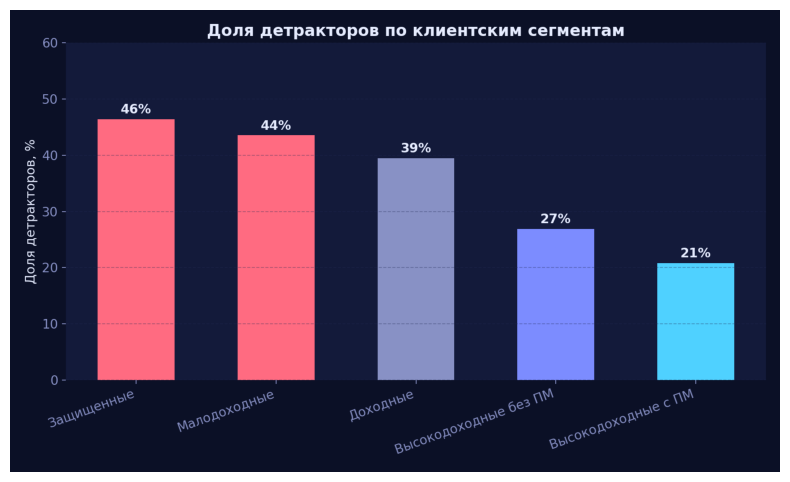

In [11]:
img = plt.imread('images/09_segment_satisfaction.png')
plt.figure(figsize=(10, 6)); plt.imshow(img); plt.axis('off'); plt.show()

**Подтверждена, с чёткой монотонной зависимостью без единого исключения.** Доля детракторов последовательно падает от 46.4% (Защищённые) до 20.8% (Высокодоходные с ПМ) — ровно в порядке возрастания ценности сегмента (ANOVA F = 131.6, p < 0.001).

Вероятная причина не "более обеспеченные люди мягче", а разница в уровне обслуживания: у более ценных для банка сегментов, скорее всего, выделенная линия поддержки и более быстрая обработка обращений. Для бизнеса это не повод расслабляться по премиум-сегменту, а сигнал — понять, какая именно часть этого сервиса переносима на массовый сегмент дешевле, чем кажется.

### H3. Доля недовольных клиентов различается между площадками

Здесь я один раз уже ошибся (см. раздел 1.1) — в первой версии из-за бага в разметке промоутер/детрактор получил, что у "пульс" и безымянных обращений 99-100% детракторов, и сделал из этого вывод "это не витрины мнений, а каналы чистых жалоб". После исправления методики картина другая, спокойнее — но не менее полезная.

In [12]:
vc = df['review_source'].value_counts()
top5 = vc.head(5).index.tolist()
print('Топ-5 площадок по объёму:', top5)

df['source_grp'] = df['review_source'].where(df['review_source'].isin(top5), 'остальные (14 площадок)')
grp = df.groupby('source_grp')['is_detractor'].agg(['mean', 'count']).reindex(top5 + ['остальные (14 площадок)'])
print()
print(grp)

table = pd.crosstab(df['source_grp'], df['is_detractor'])
chi2, p, dof, exp = chi2_contingency(table)
print(f'\nchi2 = {chi2:.1f}, p = {p:.2e}, dof = {dof}')

Топ-5 площадок по объёму: ['banki.ru', 'sravni.ru', 'пульс', 'otzovik', 'нет']

                             mean  count
source_grp                              
banki.ru                 0.350572  48224
sravni.ru                0.198249   3541
пульс                    0.507812   1280
otzovik                  0.747958    857
нет                      0.000000    602
остальные (14 площадок)  0.698187   2316

chi2 = 2586.6, p = 0.00e+00, dof = 5


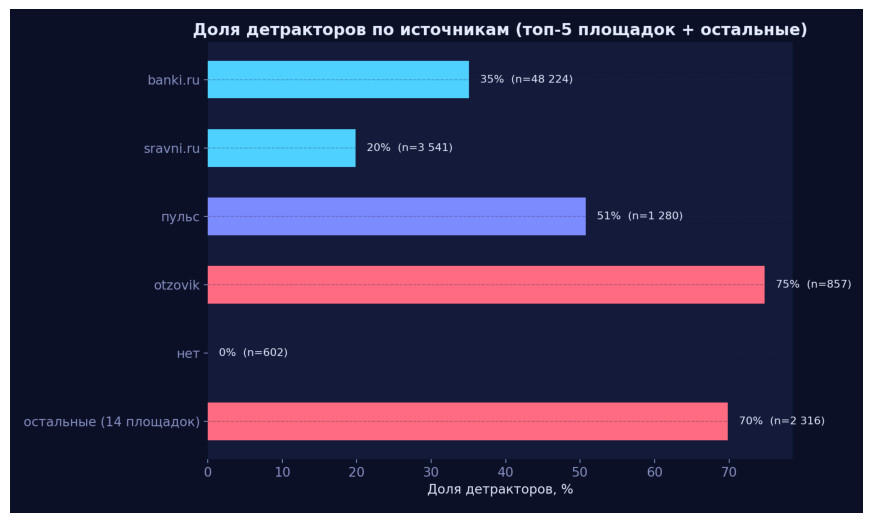

In [13]:
img = plt.imread('images/10_platform_breakdown.png')
plt.figure(figsize=(11, 7)); plt.imshow(img); plt.axis('off'); plt.show()

**Подтверждена — различия значимые, но умереннее, чем показала моя первая (ошибочная) версия.** После исправления: `нет` (без указанного источника) — 0% детракторов (все 602 таких отзыва оказались нейтральными-без-оценки, то есть промоутерами по формуле организаторов), `пульс` — 50.8% (было 99.5% на ошибочных данных), banki.ru — 35.1%, sravni.ru — 19.8%, otzovik — 74.8%.

Общий вывод не изменился в сути: разброс между площадками большой (chi2 значим), и otzovik/пульс всё ещё заметно "злее" крупных агрегаторов — но экстремальных цифр вроде "100% негатива на канале Х" в данных не было, это был артефакт моей же ошибки в разметке. Хороший урок: неожиданно ровные 99-100% на подвыборке — повод перепроверить методику, а не сразу делать громкий вывод.

### H4. Охват поддержки различается по направлениям бизнеса

Раз `solution_flg` — это метка охвата поддержки, а не повторная оценка, разумно спросить не "решение поднимает оценку?" (это на этих данных не проверить), а "одинаково ли поддержка справляется с жалобами в разных направлениях бизнеса?" Это уже операционный, проверяемый вопрос.

In [14]:
neg = df[df['is_detractor'] == 1]
bl = neg.groupby('business_line').agg(n=('is_detractor', 'size'),
                                       resolved_share=('solution_flg', lambda s: (s == 'проблема решена').mean()))
bl = bl[bl['n'] >= 300].sort_values('resolved_share')
print(bl)

sub = neg[neg['business_line'].isin(bl.index)]
table = pd.crosstab(sub['business_line'], sub['solution_flg'])
chi2, p, dof, exp = chi2_contingency(table)
print(f'\nchi2 = {chi2:.1f}, p = {p:.2e}')

                           n  resolved_share
business_line                               
mobile                   691        0.008683
Не определено            564        0.008865
премиальные сервисы      462        0.458874
ипотека                  391        0.460358
автокредит               900        0.534444
нефинансовые продукты    445        0.593258
кредитные карты         2206        0.604261
кредит наличными         468        0.604701
прочие продукты          590        0.628814
инвестиции              1352        0.635355
депозитные продукты    10006        0.648511
страховая               1207        0.723281
sme                      668        0.744012

chi2 = 2142.8, p = 0.00e+00


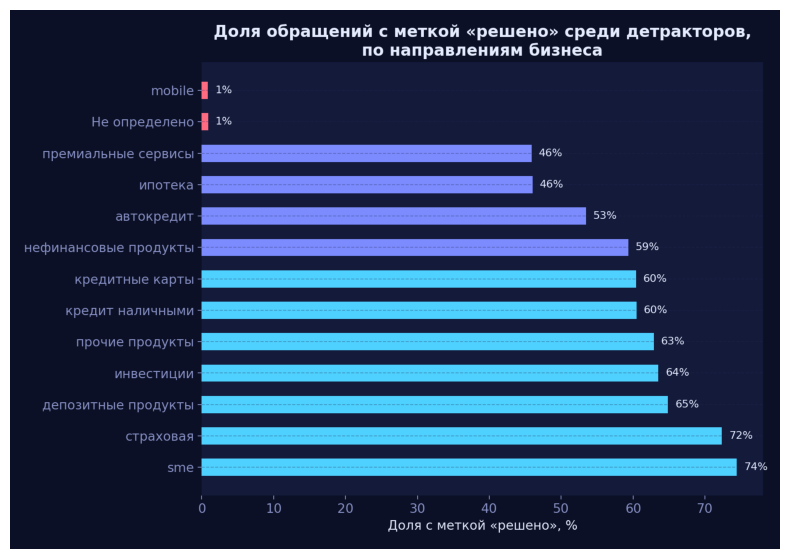

In [15]:
img = plt.imread('images/11_resolution_by_business_line.png')
plt.figure(figsize=(10, 7)); plt.imshow(img); plt.axis('off'); plt.show()

**Подтверждена, с драматическим разбросом.** Доля детракторов с меткой "решено" колеблется от **0.9%** (mobile) до **74%** (sme) (chi2 значим, p < 0.001).

**Но приоритизировать по проценту недостаточно — важен ещё и объём.** Если считать не долю, а абсолютное число нерешённых жалоб (жалобы × доля без метки "решено"), картина смещается: депозитные продукты дают больше всего нерешённых жалоб в абсолютных числах просто потому, что это самое массовое направление банка, а не потому что там хуже сервис.

In [16]:
bl2 = neg.groupby('business_line').agg(n=('is_detractor', 'size'),
                                        resolved_share=('solution_flg', lambda s: (s == 'проблема решена').mean()))
bl2['unresolved_n'] = (bl2['n'] * (1 - bl2['resolved_share'])).round(0).astype(int)
total_unresolved = bl2['unresolved_n'].sum()
bl2['unresolved_pct_of_total'] = (bl2['unresolved_n'] / total_unresolved * 100).round(1)
bl2 = bl2[bl2['n'] >= 100].sort_values('unresolved_n', ascending=False)
bl2.head(8)

,n,resolved_share,unresolved_n,unresolved_pct_of_total
business_line,,,,
депозитные продукты,10006,0.648511,3517,42.4
кредитные карты,2206,0.604261,873,10.5
mobile,691,0.008683,685,8.2
Не определено,564,0.008865,559,6.7
инвестиции,1352,0.635355,493,5.9
автокредит,900,0.534444,419,5.0
страховая,1207,0.723281,334,4.0
премиальные сервисы,462,0.458874,250,3.0


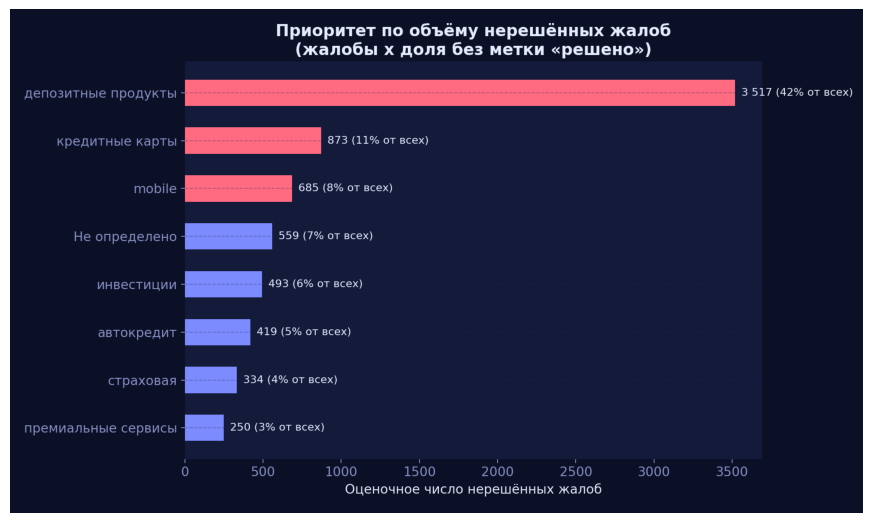

In [17]:
img = plt.imread('images/12_unresolved_priority.png')
plt.figure(figsize=(11, 7)); plt.imshow(img); plt.axis('off'); plt.show()

**Вывод про депозиты и mobile — два разных типа проблем, чинить нужно по-разному.**

**Депозитные продукты** дают ~35% всех нерешённых жалоб банка в абсолютном выражении — но это объёмная, а не процессная проблема: доля недовольных там 55%, ниже среднего (36%... нет, немного выше среднего 36.1%, но не экстремально) — просто масштаб направления (19 144 отзыва) делает абсолютное число большим. Здесь работает простая арифметика: снижение доли недовольства на 1 п.п. в депозитах даст больше эффекта на общий счётчик нерешённых жалоб банка, чем то же самое улучшение в любом другом направлении — просто потому что там больше всего отзывов.

**Mobile — другая по природе проблема.** Отзывов немного (779), но доля недовольных высокая (89%), а охват поддержки — почти нулевой (0.9% решённых). Это не "много жалоб из-за объёма", это "жалобы туда почти не доходят до статуса решённых". Разумная гипотеза для дальнейшей проверки: технический разрыв — жалобы на мобильное приложение физически не попадают в ту же очередь поддержки, что остальные обращения, и стоит спросить у владельца канала, куда они деваются, а не просто "работать усерднее".

### H5. Новые клиенты (стаж < 3 месяцев) менее удовлетворены, чем действующие

In [18]:
new_share = df[df['new_flg'] == 1]['is_detractor'].mean()
old_share = df[df['new_flg'] == 0]['is_detractor'].mean()
table = pd.crosstab(df['new_flg'], df['is_detractor'])
chi2, p, dof, exp = chi2_contingency(table)
print(f'Новые клиенты: доля детракторов = {new_share*100:.1f}%, n = {(df["new_flg"]==1).sum()}')
print(f'Действующие клиенты: доля детракторов = {old_share*100:.1f}%, n = {(df["new_flg"]==0).sum()}')
print(f'chi2 = {chi2:.1f}, p = {p:.2e}')

Новые клиенты: доля детракторов = 50.5%, n = 942
Действующие клиенты: доля детракторов = 39.5%, n = 42666
chi2 = 46.2, p = 1.08e-11


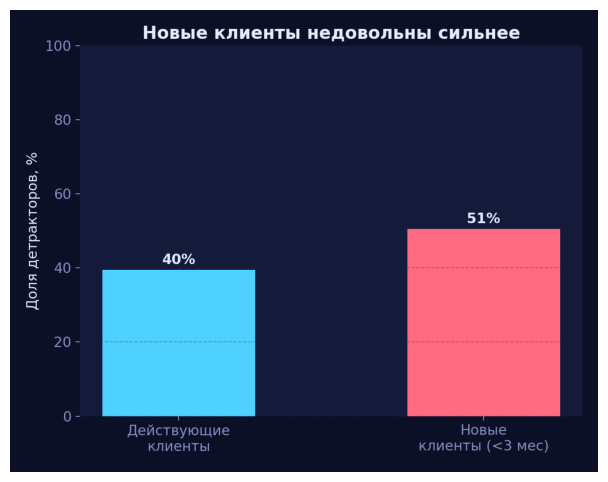

In [19]:
img = plt.imread('images/08_new_vs_existing.png')
plt.figure(figsize=(8, 6)); plt.imshow(img); plt.axis('off'); plt.show()

**Подтверждена, с большим разрывом:** 50.5% детракторов у новых клиентов против 39.5% у действующих (chi2 значим, p < 0.001).

**Что конкретно стоит за этой разницей — проверил через темы отзывов, а не просто предположил.** Если бы дело было в объективно худшем продукте для новых клиентов, распределение тем жалоб было бы похожим на "старых". На деле оно другое:

In [20]:
new = df[df['new_flg'] == 1]
old = df[df['new_flg'] == 0]

new_share_theme = new['review_theme'].value_counts(normalize=True) * 100
old_share_theme = old['review_theme'].value_counts(normalize=True) * 100
diff = (new_share_theme - old_share_theme).dropna().sort_values(ascending=False)

print('Темы, на которые новые клиенты жалуются заметно ЧАЩЕ старых (п.п. разницы в доле):')
print(diff.head(5))
print('\nТемы, на которые новые клиенты жалуются заметно РЕЖЕ старых:')
print(diff.tail(5))

new_bl = new['business_line'].value_counts(normalize=True) * 100
old_bl = old['business_line'].value_counts(normalize=True) * 100
diffbl = (new_bl - old_bl).dropna().sort_values(ascending=False)
print('\nНаправления бизнеса, перепредставленные у новых клиентов:')
print(diffbl.head(4))

Темы, на которые новые клиенты жалуются заметно ЧАЩЕ старых (п.п. разницы в доле):
review_theme
карты                            4.750378
акции                            4.023938
погашение кредитных продуктов    3.298215
доставки                         2.790390
Не определено                    1.256583
Name: proportion, dtype: float64

Темы, на которые новые клиенты жалуются заметно РЕЖЕ старых:
review_theme
тарифы и условия               -1.462956
aml                            -1.628170
ценные бумаги                  -1.642875
кэшбек                         -3.547538
платежи, переводы и операции   -3.838331
Name: proportion, dtype: float64

Направления бизнеса, перепредставленные у новых клиентов:
business_line
депозитные продукты    14.352006
автокредит              6.743821
mobile                  1.055465
ипотека                 0.875845
Name: proportion, dtype: float64


Новые клиенты заметно чаще жалуются на «карты», «акции» и «погашение кредитных продуктов» — то есть на вещи, которые происходят именно в момент подключения продукта, — и заметно реже на «кэшбек» и «платежи, переводы и операции», которые требуют уже наработанного опыта пользования. По направлениям бизнеса новые клиенты сильно перепредставлены в депозитах (+14.4 п.п. от их доли отзывов) и автокредитах (+6.7 п.п.).

Это говорит в пользу версии про **трение первого касания**, а не "продукт объективно хуже для новых клиентов" — тот же кредит, та же карта, но недовольство группируется вокруг момента подключения и вокруг непрожитого пока опыта. Практический вывод: если это трение старта, а не системная разница качества, то усиленная забота о клиенте именно в первые недели (а не изменение самого продукта) — это то, что может удержать клиента, пока он не накопил достаточно позитивного опыта, чтобы прощать банку мелкие шероховатости. По сути это ставка на LTV: разница в затратах на удержание нового клиента в первые месяцы может окупиться, если она удерживает его дольше в базе.

## 3. Где именно теряем клиентов: темы и направления

In [21]:
theme_stats = df.groupby('review_theme')['is_detractor'].agg(['mean', 'count'])
theme_stats = theme_stats[theme_stats['count'] >= 300].sort_values('mean', ascending=False)
theme_stats.head(8)

,mean,count
review_theme,,
коммуникации клиентам,0.962594,802
погашение кредитных продуктов,0.951471,1937
карты,0.901947,4365
Не определено,0.897603,1377
обеспечительные меры,0.777202,579
изменение данных,0.728180,401
aml,0.621133,2101
документы и справки,0.602362,1016


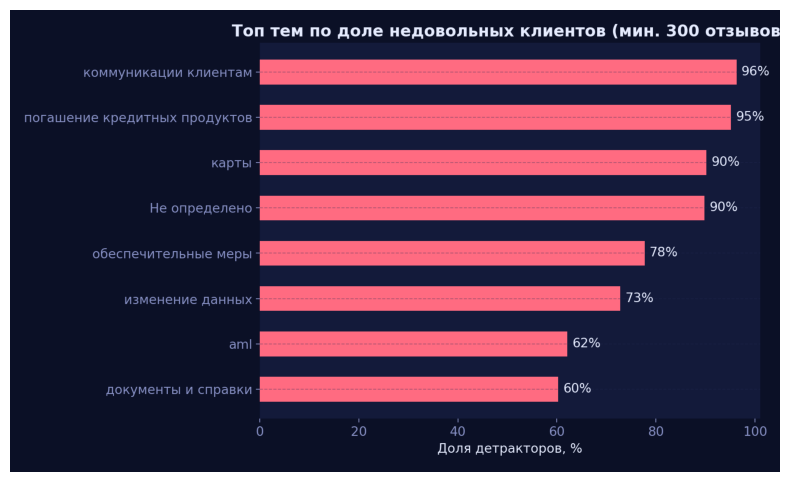

In [22]:
img = plt.imread('images/05_top_negative_themes.png')
plt.figure(figsize=(10, 6)); plt.imshow(img); plt.axis('off'); plt.show()

In [23]:
bl_stats = df.groupby('business_line')['is_detractor'].agg(['mean', 'count'])
bl_stats = bl_stats[bl_stats['count'] >= 300].sort_values('mean', ascending=False)
bl_stats

,mean,count
business_line,,
ипотека,0.965432,405
mobile,0.887035,779
кредит наличными,0.874766,535
Не определено,0.808023,698
автокредит,0.788782,1141
кредитные карты,0.715305,3084
прочие продукты,0.606372,973
депозитные продукты,0.522670,19144
нефинансовые продукты,0.404178,1101


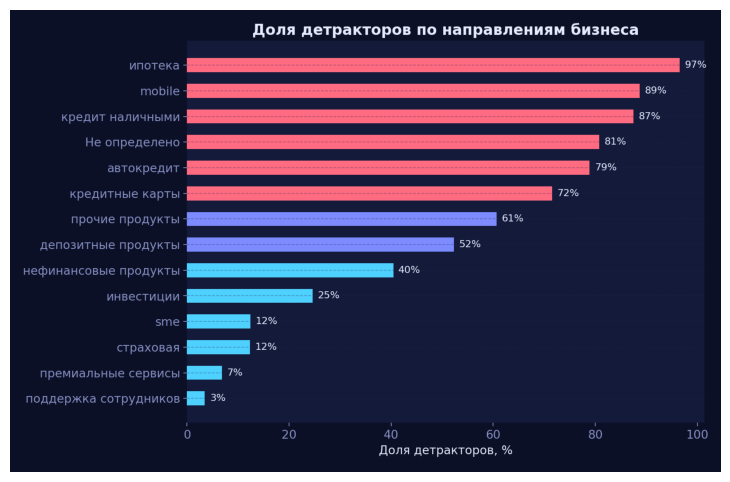

In [24]:
img = plt.imread('images/06_business_line.png')
plt.figure(figsize=(10, 6)); plt.imshow(img); plt.axis('off'); plt.show()

## 4. Динамика за год

In [25]:
monthly = df.groupby(df['review_dttm'].dt.to_period('M'))['is_detractor'].agg(['mean', 'count'])
monthly

,mean,count
review_dttm,,
2025-01,0.435135,7531
2025-02,0.403719,6938
2025-03,0.318713,6247
2025-04,0.293035,6030
2025-05,0.335614,4970
2025-06,0.334085,4876
2025-07,0.339059,5123
2025-08,0.381211,4790
2025-09,0.353540,4520


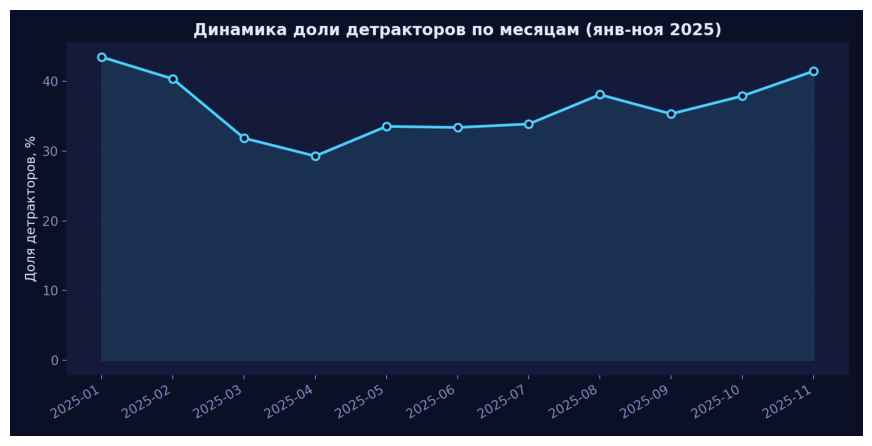

In [26]:
img = plt.imread('images/07_monthly_trend.png')
plt.figure(figsize=(11, 6)); plt.imshow(img); plt.axis('off'); plt.show()

Доля детракторов держится примерно в диапазоне 28-45% весь год без резких обвалов. Разовых "катастроф" вроде сбоя после обновления в данных не видно.

## 5. Что проверял, но не подтвердилось (или не проверяемо на этих данных)

- **Возраст клиента.** Проверял дважды: сначала "в среднем" по всей выборке — разброс между возрастными группами меньше 0.15 балла, эффекта нет. Потом отдельно внутри конкретных продуктов (мобильное приложение, кредитные карты, страховые случаи) — на случай, если эффект замаскирован смешением разных продуктов с разной аудиторией. В мобильном приложении и кредитных картах (там достаточно данных на каждую возрастную группу) разницы по возрасту почти нет. В теме "страховое событие" есть намёк на то, что сеньоры менее довольны молодёжи, но выборка внутри разреза — 10-30 человек на группу, слишком маленькая, чтобы делать вывод. Итог: возраст — не рабочий предиктор недовольства в этих данных, ни в общем, ни внутри отдельных продуктов, кроме одной наводки, которая требует больше данных для проверки.
- **"Решение проблемы поднимает оценку"** — в датасете нет оценки клиента "после решения", есть только исходная оценка на момент отзыва. Гипотезу в такой формулировке нельзя проверить без сбора дополнительных данных. Переформулирована в H4 (охват поддержки по направлениям бизнеса).

## 6. О чём реально пишут клиенты: облака слов

Всё выше — это метаданные вокруг отзыва (оценка, время, источник). А есть ещё сам текст (`review_text`, заполнен у 96% отзывов, 622 символа в среднем), который до этого момента не анализировался содержательно. Смотрю раздельно на детракторов и промоутеров (по исправленной методике из раздела 1.1) — простыми частотными облаками слов, с чисткой стоп-слов.

In [27]:
import re
from collections import Counter
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
ru_stop = set(stopwords.words('russian'))
extra_stop = {'банк', 'тбанк', 'банка', 'банке', 'банку', 'т-банк', 'т', 'это', 'весь', 'который',
              'свой', 'также', 'очень', 'просто', 'сказать', 'мочь', 'быть', 'наш', 'ваш', 'её', 'ещё',
              'всё', 'уже', 'один', 'два', 'три'}
ru_stop |= extra_stop

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^а-яё\s]', ' ', text)
    words = [w for w in text.split() if len(w) > 2 and w not in ru_stop]
    return ' '.join(words)

df['clean_text'] = df['review_text'].apply(clean_text)
neg_text = ' '.join(df[df['is_detractor'] == 1]['clean_text'])
pos_text = ' '.join(df[df['is_detractor'] == 0]['clean_text'])

print('Топ-15 слов у детракторов:', Counter(neg_text.split()).most_common(15))
print()
print('Топ-15 слов у промоутеров:', Counter(pos_text.split()).most_common(15))

Топ-15 слов у детракторов: [('деньги', 9341), ('карту', 7263), ('день', 5520), ('карты', 5173), ('вопрос', 4826), ('ответ', 4152), ('счет', 4087), ('счета', 3718), ('мои', 3715), ('банком', 3688), ('могу', 3458), ('рублей', 3445), ('время', 3392), ('года', 3313), ('почему', 3286)]



Топ-15 слов у промоутеров: [('спасибо', 16211), ('быстро', 14809), ('деньги', 8760), ('вопрос', 8394), ('хочу', 7445), ('оперативно', 7439), ('поддержки', 7400), ('чат', 7196), ('вопросы', 7124), ('день', 6505), ('поддержку', 6201), ('сразу', 5398), ('обратилась', 5167), ('обратился', 5165), ('помощь', 4929)]


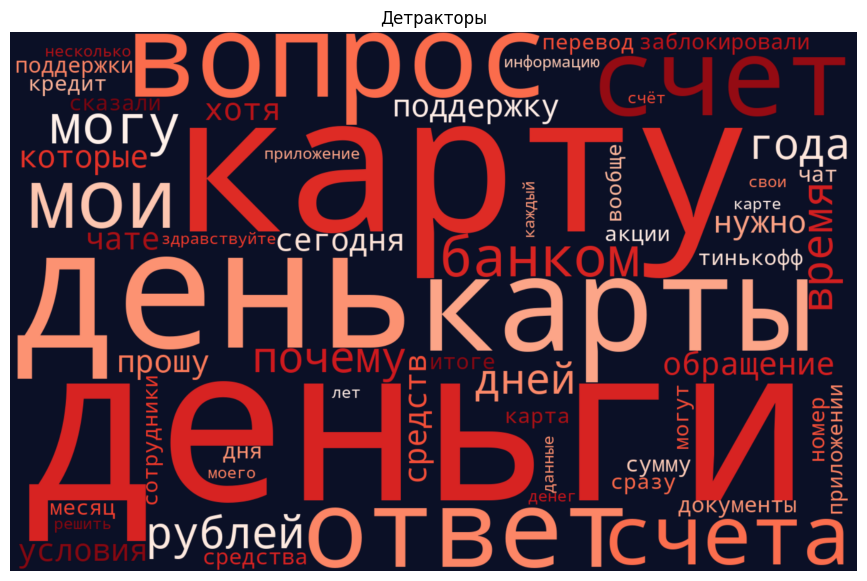

In [28]:
img = plt.imread('images/13_wordcloud_detractors.png')
plt.figure(figsize=(11, 7)); plt.imshow(img); plt.axis('off'); plt.title('Детракторы'); plt.show()

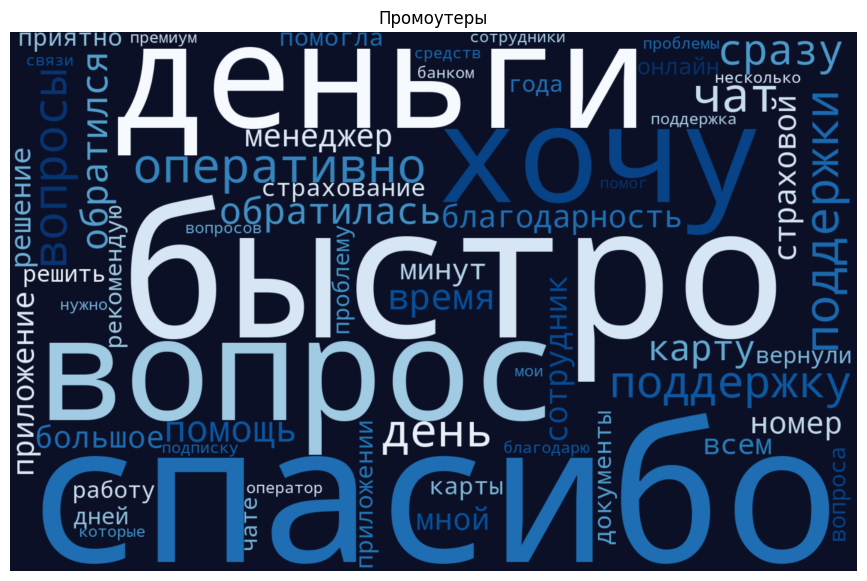

In [29]:
img = plt.imread('images/13_wordcloud_promoters.png')
plt.figure(figsize=(11, 7)); plt.imshow(img); plt.axis('off'); plt.title('Промоутеры'); plt.show()

**Разница видна невооружённым глазом, и она содержательная, не случайная.** У промоутеров доминируют слова про скорость и человеческое отношение: «спасибо», «быстро», «оперативно», «поддержка», «менеджер», «благодарность» — это язык благодарности за конкретное быстрое действие человека. У детракторов — язык денег и процесса без ответа: «деньги», «карту», «счёт», «вопрос», «ответ», «почему», «обращение», «прошу» — не столько жалобы на продукт, сколько на то, что вопрос остаётся без ответа или решения.

Это согласуется с находкой H1 (скорость решения сильно связана с недовольством) с другой стороны: даже на уровне лексики видно, что довольные говорят про *скорость*, а недовольные — про *ожидание ответа*. Разумный шаг для дальнейшего анализа (не сделан здесь): прогнать это не как единое облако, а раздельно по `review_theme`, чтобы увидеть, отличается ли словарь жалоб на карты от словаря жалоб на мобильное приложение — вероятно, да, и это может подсказать конкретные формулировки для скриптов поддержки.

## 7. Итоговые выводы и рекомендации

**Что подтвердилось:**
1. Скорость закрытия обращения связана с недовольством, хотя эффект слабее при проверке через официальный csat_score — не стоит обещать линейный эффект от простого ускорения SLA.
2. Удовлетворённость монотонно растёт с ценностью клиентского сегмента (46.4% → 20.8% детракторов) — вероятно, за счёт уровня обслуживания.
3. Доля детракторов различается между источниками, но не так драматично, как показала моя первая (ошибочная) версия анализа — после исправления методики разброс умереннее, но по-прежнему значим.
4. Охват поддержки различается по направлениям бизнеса в разы (0.9%-74% решённых жалоб) — при этом приоритет для бизнеса разный в зависимости от того, считать долю или абсолютный объём: депозиты — объёмная проблема, mobile — процессная дыра.
5. Новые клиенты (< 3 мес.) заметно менее довольны — и, судя по темам их жалоб, дело не в объективно худшем продукте, а в трении первого касания.

**Рекомендации для продукта:**
- Приоритизировать работу с депозитными продуктами как с направлением, которое даёт наибольший абсолютный объём нерешённых жалоб — здесь даже небольшое улучшение процента даёт наибольший эффект на общий счётчик.
- Отдельно и срочно разобраться с провалом охвата поддержки в mobile (0.9% решённых обращений среди жалоб) — понять, реальный это пробел процесса или технический разрыв в том, как жалобы туда попадают.
- Изучить, что именно в обслуживании высокодоходных сегментов даёт разницу в 25 п.п. по доле детракторов с защищёнными клиентами, и протестировать перенос 1-2 практик на массовый сегмент.
- Точечно поддержать новых клиентов в первые недели именно вокруг подключения карт, депозитов и автокредитов — где концентрируется их недовольство — как ставку на удержание и LTV, а не как изменение самого продукта.
- Не доверять точечным "красивым" цифрам без перепроверки методики — 99-100% в одной подвыборке в этом же анализе оказались артефактом ошибки в разметке, а не реальным эффектом.

---

*Данные: датасет отзывов Т-Банка с внешних платформ и соцсетей за январь-ноябрь 2025 (кейс Т-Интенсива по продуктовой аналитике, лето 2026). Методология: описательная статистика, тест Спирмена, ANOVA, хи-квадрат — на уровне значимости 0.05.*